# **YOLO11 Helmet Detection**

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 kB 9.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
from google.colab import drive
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
model = YOLO("yolo11n.pt")

In [5]:
dataset_path = '/content/drive/MyDrive/helmet_detection_yolo'

In [6]:
save_path = dataset_path + "/runs"

## Train Model

In [ ]:
results = model.train(
    data='/content/helmet_local/data.yaml',
    epochs=40,
    imgsz=640,
    batch=16,
    project=save_path,
    name="exp02_yolo11n_40epochs",
    exist_ok=True
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_local/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp02_yolo11n_40epochs, nbs=64, nms=None, opset=None, optim

## Validate Model

In [ ]:
best_model = YOLO(save_path + "/exp02_yolo11n_40epochs/weights/best.pt")

metrics = best_model.val()

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1663.0±446.6 MB/s, size: 67.0 KB)
val: Scanning /content/helmet_local/valid/labels.cache... 372 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 372/372 67.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.5it/s 6.8s
                   all        372        660      0.855      0.883      0.925      0.592
           With Helmet        215        338      0.882      0.941       0.96      0.667
        Without Helmet        208        322      0.829      0.826       0.89      0.517
Speed: 3.0ms preprocess, 5.2ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val


## Function for showing the image

In [7]:
def show_img(results):
  result = results[0]

  im = result.plot(
      line_width=1,
      font_size=10,
      conf = False
  )

  plt.figure(figsize=(8,8))
  plt.imshow(im)
  plt.axis("off")

## Predict on a Single Image

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 0.1±0.1 MB/s, size: 66.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/helmet_detection_yolo/valid/labels.cache... 372 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 372/372 55.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.3it/s 10.3s
                   all        372        660      0.855      0.883      0.925      0.592
           With Helmet        215        338      0.882      0.941       0.96      0.667
        Without Helmet        208        322      0.829      0.826       0.89      0.517
Speed: 3.5ms preprocess, 6.5ms inference, 0.

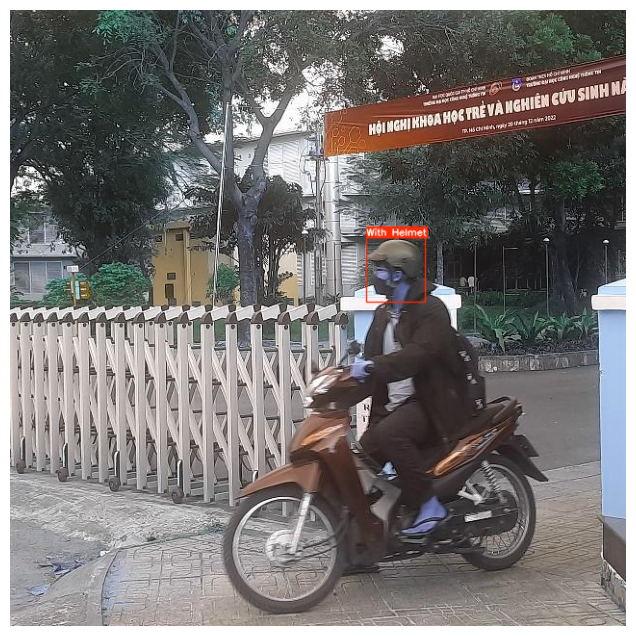

In [9]:
best_model = YOLO(save_path + "/exp02_yolo11n_40epochs/weights/best.pt")

metrics = best_model.val(data=dataset_path + "/data.yaml")

test_image = dataset_path+'/test/images/test24_jpg.rf.7f70064dfc29961bcabfb4e63c470022.jpg'

results = best_model.predict(
    source= test_image,
    conf=0.25,
    iou=0.50,
    save=True
)

show_img(results[0])

## Prediction on Test Folder

In [10]:
results = best_model.predict(
    source= dataset_path + "/test/images",
    conf=0.25,
    iou=0.50,
    save=True
)


image 1/149 /content/drive/MyDrive/helmet_detection_yolo/test/images/BikesHelmets102_png.rf.b771e83db4052e5e48900f1d9f4ee68e.jpg: 640x640 2 With Helmets, 10.9ms
image 2/149 /content/drive/MyDrive/helmet_detection_yolo/test/images/BikesHelmets110_png.rf.108cd2cfde7b038eea459b97539f7922.jpg: 640x640 4 Without Helmets, 34.9ms
image 3/149 /content/drive/MyDrive/helmet_detection_yolo/test/images/BikesHelmets113_png.rf.ce74cc3e9c8d03be417b6cd16444261e.jpg: 640x640 1 With Helmet, 1 Without Helmet, 16.7ms
image 4/149 /content/drive/MyDrive/helmet_detection_yolo/test/images/BikesHelmets143_png.rf.caf0aacf12adfbfa16b20b8c3563a803.jpg: 640x640 6 Without Helmets, 14.6ms
image 5/149 /content/drive/MyDrive/helmet_detection_yolo/test/images/BikesHelmets158_png.rf.71cdb3536b840ccc2f0e44d1e5ce36e3.jpg: 640x640 1 With Helmet, 12.2ms
image 6/149 /content/drive/MyDrive/helmet_detection_yolo/test/images/BikesHelmets183_png.rf.1f9ebed2be11011e589ec58d1def89c1.jpg: 640x640 1 With Helmet, 10.7ms
image 7/149 

In [11]:
result = results[0]
result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'With Helmet', 1: 'Without Helmet'}
obb: None
orig_img: array([[[ 26,  30,  41],
        [ 28,  32,  43],
        [ 30,  34,  45],
        ...,
        [ 67,  87,  92],
        [ 67,  87,  92],
        [ 67,  87,  92]],

       [[ 26,  30,  41],
        [ 28,  32,  43],
        [ 30,  34,  45],
        ...,
        [ 65,  85,  90],
        [ 65,  85,  90],
        [ 65,  85,  90]],

       [[ 26,  30,  41],
        [ 27,  31,  42],
        [ 27,  34,  43],
        ...,
        [ 62,  82,  87],
        [ 62,  82,  87],
        [ 62,  82,  87]],

       ...,

       [[102, 112,  96],
        [105, 115,  99],
        [108, 118, 102],
        ...,
        [248, 249, 247],
        [248, 249, 247],
        [248, 249, 247]],

       [[103, 113,  97],
        [106, 116, 100],
        [108, 118, 102],
        ...,
        [248, 249, 247],


In [12]:
result.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.], device='cuda:0')
conf: tensor([0.7231, 0.6253], device='cuda:0')
data: tensor([[386.4609,  30.2125, 479.1906, 129.4009,   0.7231,   0.0000],
        [218.9568, 117.2231, 278.0602, 197.1436,   0.6253,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([2, 6])
xywh: tensor([[432.8257,  79.8067,  92.7296,  99.1885],
        [248.5085, 157.1834,  59.1033,  79.9205]], device='cuda:0')
xywhn: tensor([[0.6763, 0.1247, 0.1449, 0.1550],
        [0.3883, 0.2456, 0.0923, 0.1249]], device='cuda:0')
xyxy: tensor([[386.4609,  30.2125, 479.1906, 129.4009],
        [218.9568, 117.2231, 278.0602, 197.1436]], device='cuda:0')
xyxyn: tensor([[0.6038, 0.0472, 0.7487, 0.2022],
        [0.3421, 0.1832, 0.4345, 0.3080]], device='cuda:0')

In [13]:
result.boxes.cls

tensor([0., 0.], device='cuda:0')

In [14]:
result.boxes.conf

tensor([0.7231, 0.6253], device='cuda:0')

In [15]:
with_helmet = 0
without_helmet = 0

for result in results:
  for box in result.boxes:

    class_id = int(box.cls)

    if class_id == 0:
      with_helmet += 1
    else:
      without_helmet += 1

print("With Helmet:", with_helmet)
print("Without Helmet:", without_helmet)

With Helmet: 177
Without Helmet: 96


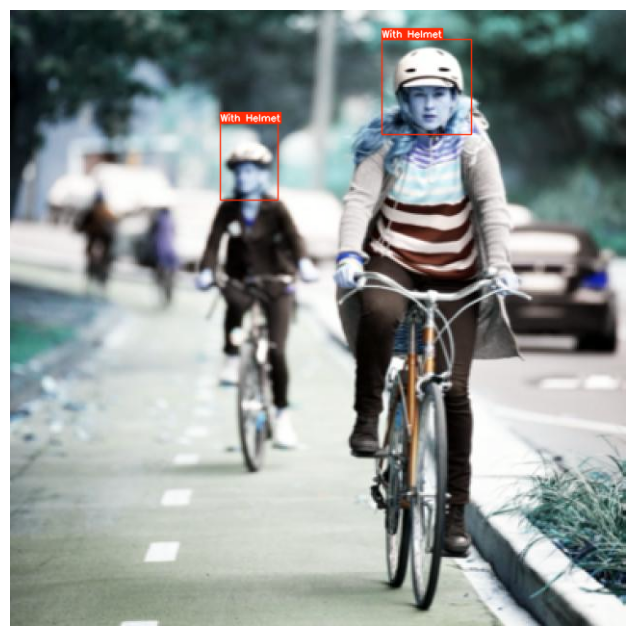

In [16]:
show_img(results)

## Upload a image to check

Saving ex3.jpg to ex3.jpg

image 1/1 /content/ex3.jpg: 640x640 1 With Helmet, 1 Without Helmet, 10.8ms
Speed: 1.1ms preprocess, 10.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


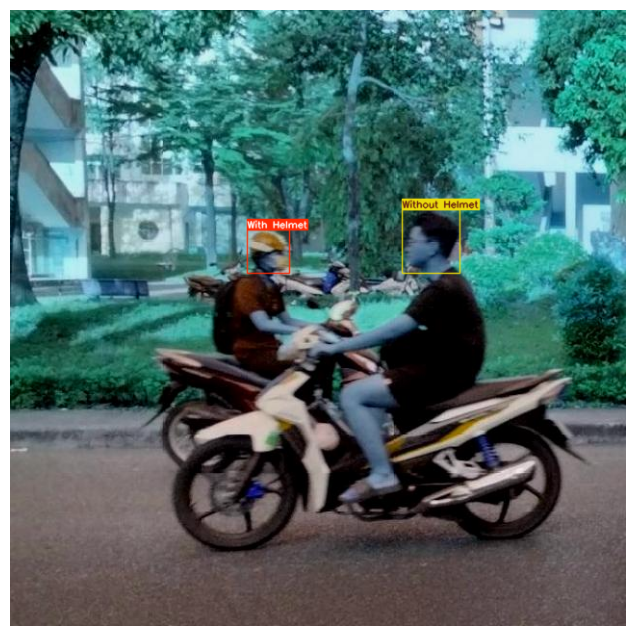

In [17]:
from google.colab import files
from IPython.display import Image, display
from pathlib import Path

uploaded = files.upload()

image_path = next(iter(uploaded))

results = best_model.predict(
    source=image_path,
    conf=0.25,
    iou=0.50,
    save=True
)

show_img(results)

In [18]:
from google.colab import files
from IPython.display import Video, display
from pathlib import Path
import subprocess

uploaded = files.upload()

video_path = next(iter(uploaded))

results = best_model.predict(
    source=video_path,
    save=True,
    line_width=1,
    show_conf=False,
    show_labels=True
)

prediction_dir = Path(results[0].save_dir)

prediction_video = next(
    file for file in prediction_dir.iterdir()
    if file.suffix.lower() in [".avi", ".mp4", ".mov", ".mkv"]
)

output_video = prediction_dir / "prediction.mp4"

subprocess.run([
    "ffmpeg",
    "-y",
    "-i",
    str(prediction_video),
    str(output_video)
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

display(Video(str(output_video), embed=True, width=1000))

Saving video_example.mp4 to video_example.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/182) /content/video_example.mp4: 384x640 3 With Helmets, 2 Without Helmets, 53.8ms
video 1/1 (frame 2/182) /content/video_example.mp4: 384x640 3 With Helmets, 2 Without Helmets, 17.8ms
video 1/1 (frame 3/182) /content/video_example.mp4: 384x640 4 With Helmets, 2 Without Helmets, 17.5ms
video 1/1 (frame 4/182) /content/video_example.mp4: 384x640 4 With Helmets, 1 Without Helmet, 17.7ms
video 